In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import fsspec
from zipfile import ZipFile
from io import BytesIO

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import warnings
warnings.filterwarnings('ignore')

In [6]:
df_q1 = pd.read_csv(
    'gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2026.zip',
    usecols=['FlightDate_utc', 'Operator', 'Hours', 'aircraft_model'],
)

print(f'Loaded {len(df_q1):,} rows')
df_q1.head(3)

Loaded 885,823 rows


,FlightDate_utc,Operator,Hours,aircraft_model
0,2026-03-31T07:44:00.000Z,ProAir Aviation GmbH,1.600000,Citation CJ4 Gen2
1,2026-03-31T20:45:00.000Z,CMH Services Aviation Inc,1.266667,Praetor 600
2,2026-03-31T14:27:52.000Z,Deer Jet,1.414444,G550


In [7]:
# Filter to C300 and P300 aircraft — using str.contains
mask_c300 = df_q1['aircraft_model'].str.contains('Challenger 300|Challenger 350|Challenger 3500', na=False)
mask_p300 = df_q1['aircraft_model'].str.contains('Phenom 300', na=False)

df_q1 = df_q1[mask_c300 | mask_p300].copy()

# Label aircraft group
df_q1['aircraft_group'] = np.where(mask_c300[df_q1.index], 'C300', 'P300')

# Label operator group — all Wheels Up entities
df_q1['operator_group'] = np.where(
    df_q1['Operator'].str.contains('Wheels Up', na=False), 'Wheels Up', 'Market'
)

# Clean hours
df_q1['Hours'] = pd.to_numeric(df_q1['Hours'], errors='coerce')
df_q1 = df_q1[df_q1['Hours'] > 0].dropna(subset=['Hours'])

print(f'Filtered to {len(df_q1):,} C300/P300 trips')
df_q1.groupby(['aircraft_group', 'operator_group'])['Hours'].count().to_frame('trips')

Filtered to 134,426 C300/P300 trips


trips
aircraft_group operator_group       
C300           Market          62807
               Wheels Up         719
P300           Market          68665
               Wheels Up        2235

In [8]:
# Q1-2026 Stats Table — mean, std, median, quartiles
stats_q1 = (
    df_q1.groupby(['aircraft_group', 'operator_group'])['Hours']
    .agg(Trips='count', Mean='mean', Std='std', Median='median',
         P25=lambda x: x.quantile(0.25), P75=lambda x: x.quantile(0.75))
    .round(2)
    .reset_index()
)

print('Q1-2026: Avg Hours per Trip — C300 vs P300 (Wheels Up vs Market)')
display(stats_q1)

Q1-2026: Avg Hours per Trip — C300 vs P300 (Wheels Up vs Market)


,aircraft_group,operator_group,Trips,Mean,Std,Median,P25,P75
0,C300,Market,62807,1.82,1.25,1.52,0.83,2.48
1,C300,Wheels Up,719,2.18,1.33,2.02,1.07,3.17
2,P300,Market,68665,1.38,0.83,1.17,0.73,1.90
3,P300,Wheels Up,2235,1.56,0.81,1.47,0.92,2.10


In [9]:
# Top 5 aircraft models by flight count
top5_models_q1 = (
    df_q1['aircraft_model'].value_counts()
    .head(5)
    .index.tolist()
)
df_q1_top5 = df_q1[df_q1['aircraft_model'].isin(top5_models_q1)]

model_order_q1 = (
    df_q1_top5.groupby('aircraft_model')['Hours'].median()
    .sort_values().index.tolist()
)

print('Top 5 models:', top5_models_q1)

Top 5 models: ['Phenom 300', 'Challenger 350', 'Challenger 300', 'Phenom 300-E', 'Challenger 3500']


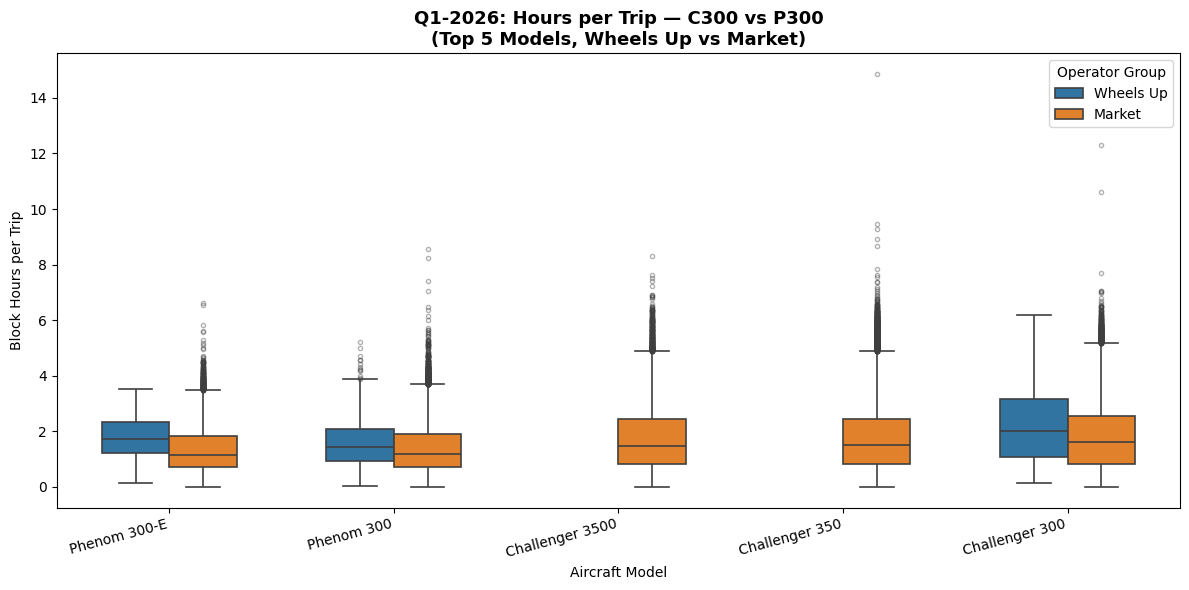

In [13]:
# Q1-2026 Box Plot — C300 vs P300, Wheels Up vs Market
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_q1_top5,
    x='aircraft_model', y='Hours',
    hue='operator_group',
    order=model_order_q1,
    hue_order=['Wheels Up', 'Market'],
    width=0.6, linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.set_title('Q1-2026: Hours per Trip — C300 vs P300\n(Top 5 Models, Wheels Up vs Market)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Aircraft Model')
ax.set_ylabel('Block Hours per Trip')
ax.legend(title='Operator Group')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Q1-2026 Cluster Analysis — load processed corridor file
corr_2026 = pd.read_csv('gs://agntworks-data-dev/wheelsup/processed/wingx/wingx_corridor_2026.csv')

#Filter to C300 + P300
mask_c300_c = corr_2026['aircraft_model'].str.contains('Challenger 300|Challenger 350|Challenger 3500', na=False)
mask_p300_c = corr_2026['aircraft_model'].str.contains('Phenom 300', na=False)
corr_q1 = corr_2026[mask_c300_c | mask_p300_c].copy()

corr_q1['aircraft_group'] = np.where(mask_c300_c[corr_q1.index], 'C300', 'P300')
corr_q1['operator_group'] = np.where(
    corr_q1['Operator'].str.contains('Wheels Up', na=False), 'Wheels Up', 'Market'
)

# Split corridor into from/to cluster, then stack both as endpoints
corr_q1[['from_cluster', 'to_cluster']] = corr_q1['corridor'].str.split('→', expand=True)

from_side  = corr_q1[['aircraft_group', 'operator_group', 'from_cluster', 'flights']].rename(columns={'from_cluster': 'cluster'})
to_side    = corr_q1[['aircraft_group', 'operator_group', 'to_cluster',   'flights']].rename(columns={'to_cluster':   'cluster'})
cluster_df = pd.concat([from_side, to_side], ignore_index=True)

cluster_df['cluster'] = cluster_df['cluster'].str.replace('_CLUSTER', '', regex=False).str.strip()

cluster_agg = (
    cluster_df.groupby(['aircraft_group', 'operator_group', 'cluster'])['flights']
    .sum().reset_index().sort_values('flights', ascending=False)
)

print('Q1-2026 Top 5 Clusters — C300:')
display(cluster_agg[cluster_agg['aircraft_group'] == 'C300'].head(10))
print('\nQ1-2026 Top 5 Clusters — P300:')
display(cluster_agg[cluster_agg['aircraft_group'] == 'P300'].head(10))

Q1-2026 Top 5 Clusters — C300:


,aircraft_group,operator_group,cluster,flights
19,C300,Market,MIAMI,9349
22,C300,Market,NEW_YORK,7672
6,C300,Market,CHICAGO,6296
1,C300,Market,ATLANTA,5366
34,C300,Market,WASHINGTON_DC,4921
7,C300,Market,DALLAS,4328
17,C300,Market,LOS_ANGELES,4101
29,C300,Market,SAN_FRANCISCO,4021
23,C300,Market,ORLANDO,3998
13,C300,Market,HOUSTON,3845



Q1-2026 Top 5 Clusters — P300:


,aircraft_group,operator_group,cluster,flights
58,P300,Market,ATLANTA,8281
74,P300,Market,MIAMI,8120
78,P300,Market,ORLANDO,5655
64,P300,Market,CHICAGO,5543
65,P300,Market,DALLAS,5114
88,P300,Market,WASHINGTON_DC,5070
77,P300,Market,NEW_YORK,4760
68,P300,Market,HOUSTON,4331
72,P300,Market,LOS_ANGELES,3262
84,P300,Market,SAN_FRANCISCO,3084


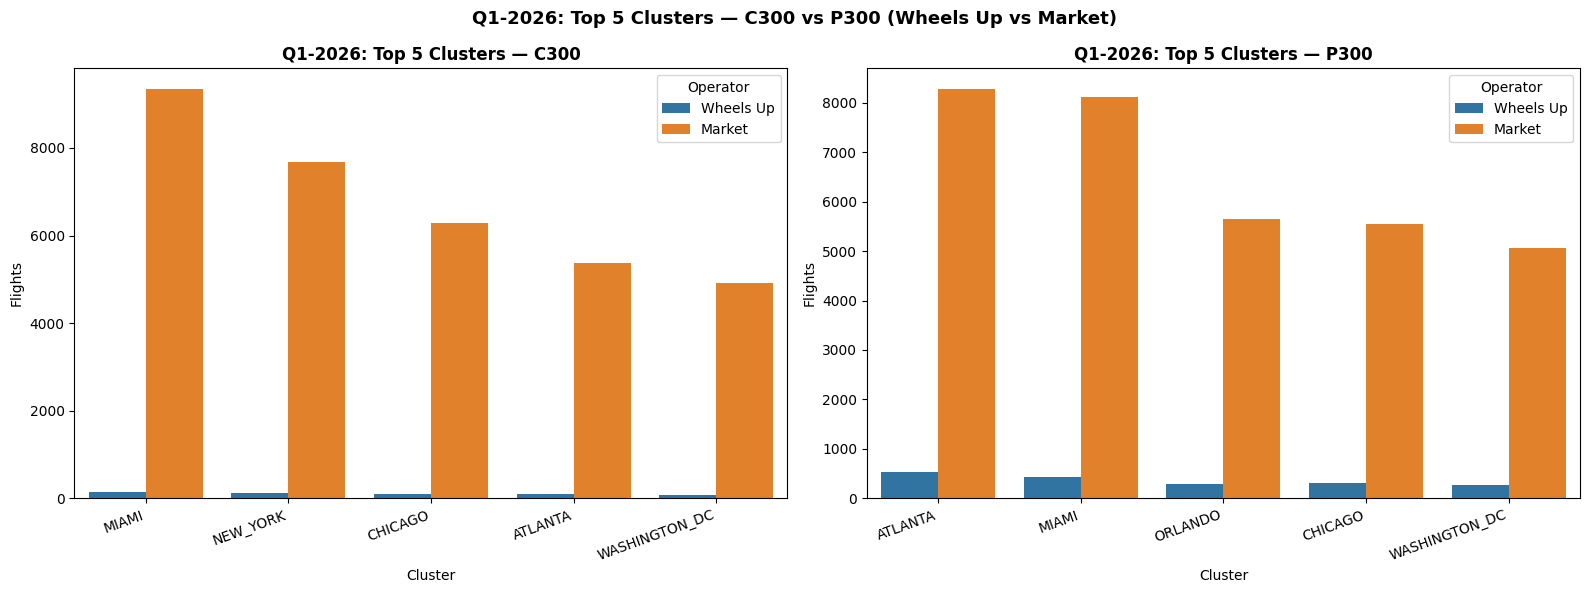

In [20]:
# Q1-2026 Cluster Bar Chart — C300 and P300 side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, grp in zip(axes, ['C300', 'P300']):
    grp_data = cluster_agg[cluster_agg['aircraft_group'] == grp]

    top5 = grp_data.groupby('cluster')['flights'].sum().nlargest(5).index.tolist()
    plot_data = grp_data[grp_data['cluster'].isin(top5)]

    sns.barplot(
        data=plot_data,
        x='cluster', y='flights',
        hue='operator_group',
        hue_order=['Wheels Up', 'Market'],
        order=top5, ax=ax
    )
    ax.set_title(f'Q1-2026: Top 5 Clusters — {grp}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Flights')
    ax.legend(title='Operator')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Q1-2026: Top 5 Clusters — C300 vs P300 (Wheels Up vs Market)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# p2

In [26]:
def load_specific_csv_from_zip(url, filename):
    """Load one specific CSV from multi-file ZIP"""
    with fsspec.open(url, 'rb') as f:
        with ZipFile(BytesIO(f.read())) as z:
            return pd.read_csv(z.open(filename))

# url_2026 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2026.zip"
url_2025 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2025.zip"
url_2024 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2024.zip"
url_2023 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2023.zip"

#  quarter-wise DataFrames (exactly matching your file names)
# 2026
quarters = [
    # (url_2026, 'WINGX_Jan26-Mar26.csv'),
    (url_2025, 'WINGX_Jan25-Mar25.csv'),
    (url_2025, 'WINGX_Apr25-Jun25.csv'),
    (url_2025, 'WINGX_Jul25-Sep25.csv'),
    (url_2025, 'WINGX_Oct25-Dec25.csv'),
    (url_2024, 'WINGX_Jan24-Mar24.csv'),
    (url_2024, 'WINGX_Apr24-Jun24.csv'),
    (url_2024, 'WINGX_Jul24-Sep24.csv'),
    (url_2024, 'WINGX_Oct24-Dec24.csv'),
    (url_2023, 'WINGX_Jan23-Mar23.csv'),
    (url_2023, 'WINGX_Apr23-Jun23.csv'),
    (url_2023, 'WINGX_Jul23-Sep23.csv'),
    (url_2023, 'WINGX_Oct23-Dec23.csv'),
]


In [27]:
# filter early, only what we need
frames = []
COLS = ['FlightDate_utc', 'Operator', 'Hours', 'aircraft_model']
for url, filename in quarters:
    with fsspec.open(url, 'rb') as f:
        with ZipFile(BytesIO(f.read())) as z:
            raw = pd.read_csv(z.open(filename), usecols=COLS, low_memory=False)
    mask_c300 = raw['aircraft_model'].str.contains('Challenger 300|Challenger 350|Challenger 3500', na=False)
    mask_cit  = raw['aircraft_model'].str.contains('Citation', na=False)
    raw = raw[mask_c300 | mask_cit].copy()
    raw['aircraft_group'] = np.where(mask_c300[raw.index], 'C300', 'Citation')
    frames.append(raw)
    print(f'{filename}: {len(raw):,} rows matched')

WINGX_Jan25-Mar25.csv: 329,677 rows matched
WINGX_Apr25-Jun25.csv: 355,801 rows matched
WINGX_Jul25-Sep25.csv: 370,204 rows matched
WINGX_Oct25-Dec25.csv: 360,187 rows matched
WINGX_Jan24-Mar24.csv: 316,240 rows matched
WINGX_Apr24-Jun24.csv: 340,213 rows matched
WINGX_Jul24-Sep24.csv: 352,927 rows matched
WINGX_Oct24-Dec24.csv: 352,016 rows matched
WINGX_Jan23-Mar23.csv: 317,794 rows matched
WINGX_Apr23-Jun23.csv: 341,906 rows matched
WINGX_Jul23-Sep23.csv: 358,343 rows matched
WINGX_Oct23-Dec23.csv: 338,576 rows matched


In [41]:
df_3yr = pd.concat(frames, ignore_index=True)

# All Wheels Up entities
df_3yr['operator_group'] = np.where(
    df_3yr['Operator'].str.contains('Wheels Up', na=False), 'Wheels Up', 'Market'
)
df_3yr['Hours']          = pd.to_numeric(df_3yr['Hours'], errors='coerce')
df_3yr['FlightDate_utc'] = pd.to_datetime(df_3yr['FlightDate_utc'], utc=True, errors='coerce')
df_3yr['year']           = df_3yr['FlightDate_utc'].dt.year
df_3yr = df_3yr[df_3yr['Hours'] > 0].dropna(subset=['Hours', 'year'])

print(f'\nTotal 3-year trips: {len(df_3yr):,}')
df_3yr.groupby(['year', 'aircraft_group', 'operator_group'])['Hours'].count().to_frame('trips')



Total 3-year trips: 4,131,350


trips
year aircraft_group operator_group         
2023 C300           Market           225179
                    Wheels Up           408
     Citation       Market          1120242
                    Wheels Up          9850
2024 C300           Market           235430
     Citation       Market          1112753
                    Wheels Up         12326
2025 C300           Market           252758
                    Wheels Up          1204
     Citation       Market          1145582
                    Wheels Up         15617
2026 Citation       Market                1

In [42]:
# 3-Year Stats Table
stats_3yr = (
    df_3yr.groupby(['year', 'aircraft_group', 'operator_group'])['Hours']
    .agg(Trips='count', Mean='mean', Std='std', Median='median',
         P25=lambda x: x.quantile(0.25), P75=lambda x: x.quantile(0.75))
    .round(2)
    .reset_index()
)

print('3-Year Avg Hours per Trip — C300 vs Citation (Wheels Up vs Market)')
display(
    stats_3yr.sort_values(['aircraft_group', 'operator_group', 'year'])
    .reset_index(drop=True)
    .style.format({'Mean': '{:.2f}', 'Std': '{:.2f}', 'Median': '{:.2f}',
                   'P25': '{:.2f}', 'P75': '{:.2f}', 'Trips': '{:,.0f}'})
    .background_gradient(subset=['Mean', 'Std'], cmap='Blues')
)

3-Year Avg Hours per Trip — C300 vs Citation (Wheels Up vs Market)


,year,aircraft_group,operator_group,Trips,Mean,Std,Median,P25,P75
0,2023,C300,Market,"225,179",1.71,1.21,1.38,0.80,2.32
1,2024,C300,Market,"235,430",1.71,1.20,1.38,0.80,2.32
2,2025,C300,Market,"252,758",1.70,1.20,1.38,0.80,2.32
3,2023,C300,Wheels Up,408,1.65,1.10,1.37,0.78,2.15
4,2025,C300,Wheels Up,"1,204",2.31,1.40,2.13,1.10,3.27
5,2023,Citation,Market,"1,120,242",1.43,0.93,1.18,0.72,1.95
6,2024,Citation,Market,"1,112,753",1.42,0.93,1.17,0.72,1.93
7,2025,Citation,Market,"1,145,582",1.42,0.94,1.16,0.72,1.95
8,2026,Citation,Market,1,1.72,nan,1.72,1.72,1.72
9,2023,Citation,Wheels Up,"9,850",1.52,0.87,1.40,0.82,2.08


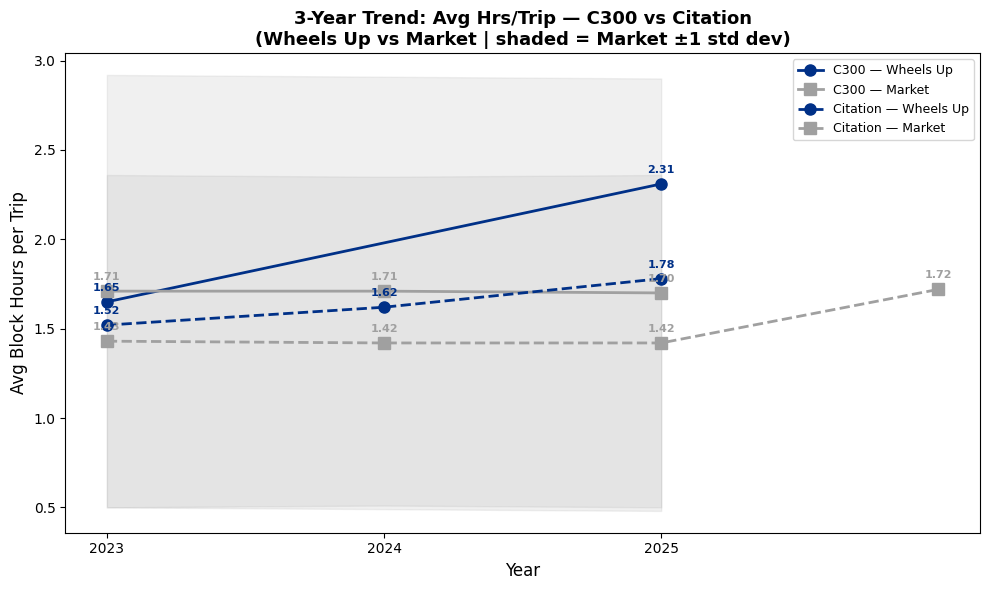

In [45]:
# 3-Year Trend Line Chart — 4 lines: C300-WU, C300-Market, Citation-WU, Citation-Market
fig, ax = plt.subplots(figsize=(10, 6))

styles = {
    ('C300',    'Wheels Up'): dict(color='#003087', linestyle='-',  marker='o', label='C300 — Wheels Up'),
    ('C300',    'Market'):    dict(color='#A0A0A0', linestyle='-',  marker='s', label='C300 — Market'),
    ('Citation','Wheels Up'): dict(color='#003087', linestyle='--', marker='o', label='Citation — Wheels Up'),
    ('Citation','Market'):    dict(color='#A0A0A0', linestyle='--', marker='s', label='Citation — Market'),
}

for (grp, op), style in styles.items():

    sub = stats_3yr[
        (stats_3yr['aircraft_group'] == grp) &
        (stats_3yr['operator_group'] == op)
    ].sort_values('year')

    if sub.empty:
        continue

    # plot line
    ax.plot(sub['year'], sub['Mean'], linewidth=2, markersize=8, **style)

    # SHADE ONLY MARKET STD DEV
    if op == "Market":
        ax.fill_between(
            sub['year'],
            sub['Mean'] - sub['Std'],
            sub['Mean'] + sub['Std'],
            color=style['color'],
            alpha=0.15
        )

    # annotate values
    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['Mean']:.2f}",
            xy=(row['year'], row['Mean']),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color=style['color'],
            fontweight='bold'
        )

ax.set_xticks([2023, 2024, 2025])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Block Hours per Trip', fontsize=12)

ax.set_title(
    '3-Year Trend: Avg Hrs/Trip — C300 vs Citation\n'
    '(Wheels Up vs Market | shaded = Market ±1 std dev)',
    fontsize=13,
    fontweight='bold'
)

ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [46]:
# Top 5 models across C300 + Citation (3-year combined)
top5_models_3yr = df_3yr['aircraft_model'].value_counts().head(5).index.tolist()
df_3yr_top5 = df_3yr[df_3yr['aircraft_model'].isin(top5_models_3yr)]

model_order_3yr = (
    df_3yr_top5.groupby('aircraft_model')['Hours'].median()
    .sort_values().index.tolist()
)
print('Top 5 models (3-year):', top5_models_3yr)

Top 5 models (3-year): ['Citation Latitude', 'Challenger 350', 'Citation XLS', 'Challenger 300', 'Citation CJ3']


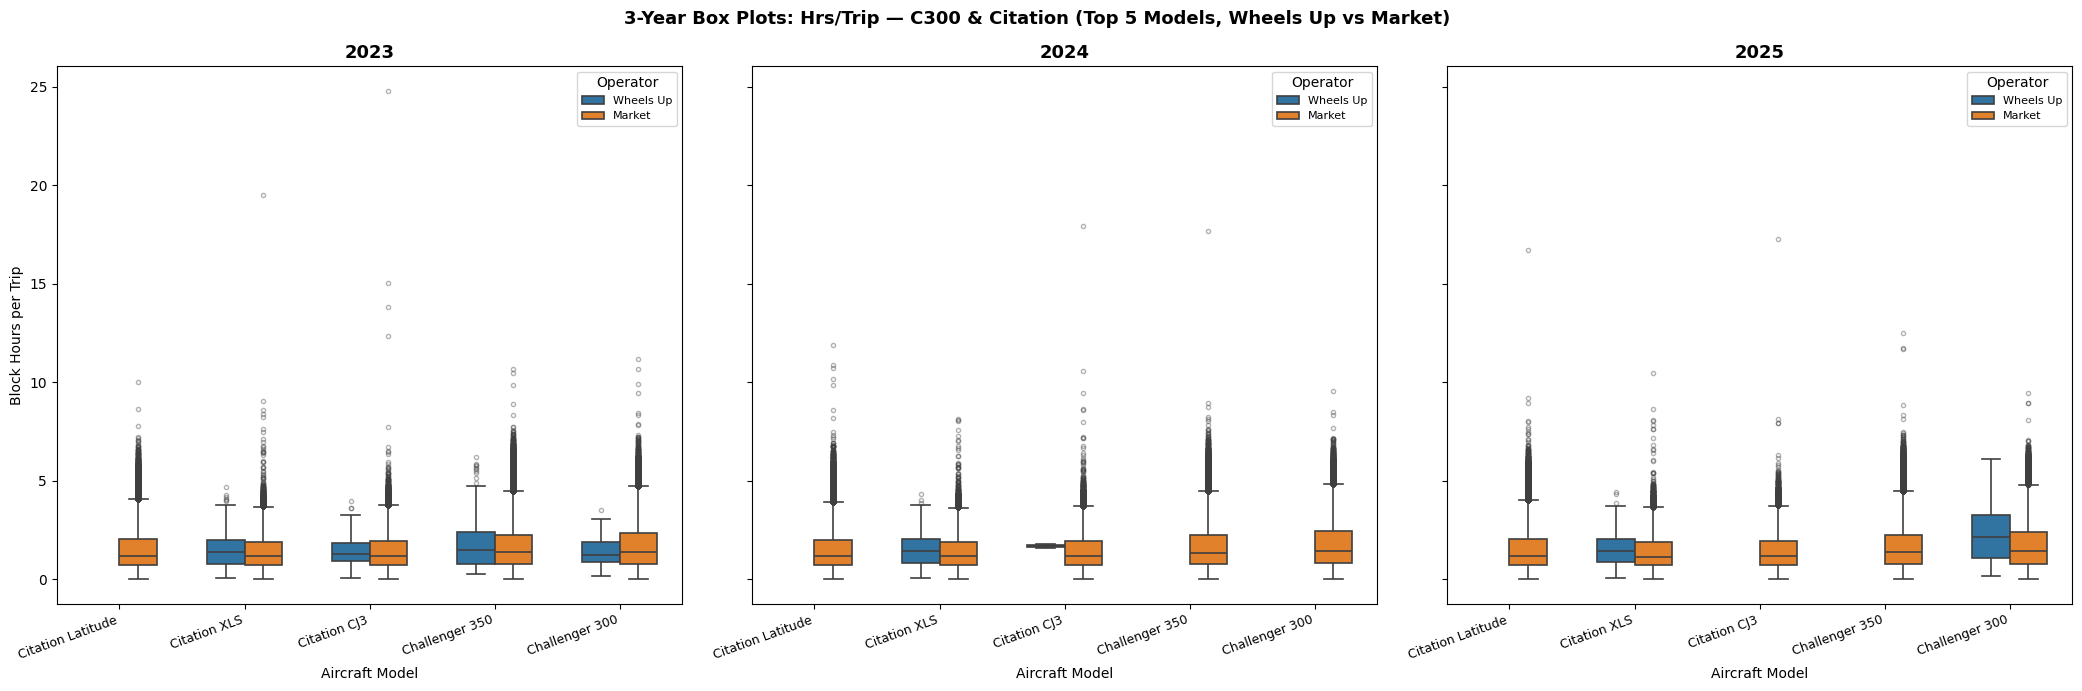

In [49]:
# 3-Year Box Plots — one subplot per year, WU vs Market
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True)

for ax, yr in zip(axes, [2023, 2024, 2025]):
    yr_data = df_3yr_top5[df_3yr_top5['year'] == yr]

    sns.boxplot(
        data=yr_data,
        x='aircraft_model', y='Hours',
        hue='operator_group',
        order=model_order_3yr,
        hue_order=['Wheels Up', 'Market'],
        width=0.6, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
        ax=ax
    )
    ax.set_title(str(yr), fontsize=13, fontweight='bold')
    ax.set_xlabel('Aircraft Model')
    ax.set_ylabel('Block Hours per Trip' if yr == 2023 else '')
    ax.legend(title='Operator', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)

fig.suptitle('3-Year Box Plots: Hrs/Trip — C300 & Citation (Top 5 Models, Wheels Up vs Market)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# Trend Summary — direction of change 2023 → 2025
print('=' * 70)
print('TREND SUMMARY: 2023 → 2025 Change in Avg Hrs/Trip')
print('=' * 70)

for grp in ['C300', 'Citation']:
    for op in ['Wheels Up', 'Market']:
        sub = stats_3yr[(stats_3yr['aircraft_group'] == grp) &
                        (stats_3yr['operator_group'] == op)].sort_values('year')
        if len(sub) < 2:
            continue

        start = sub.iloc[0]
        end   = sub.iloc[-1]
        delta = end['Mean'] - start['Mean']
        pct   = (delta / start['Mean']) * 100
        trend = 'UP ↑' if delta > 0.05 else ('DOWN ↓' if delta < -0.05 else 'STABLE →')
        std_chg = end['Std'] - start['Std']
        discipline = ('MORE disciplined (std ↓)' if std_chg < -0.05
                      else 'LESS disciplined (std ↑)' if std_chg > 0.05
                      else 'Consistent spread (std stable)')

        print(f'\n[{grp} — {op}]')
        print(f'  {int(start["year"])}: mean={start["Mean"]:.2f} hrs  std={start["Std"]:.2f}')
        print(f'  {int(end["year"])}: mean={end["Mean"]:.2f} hrs  std={end["Std"]:.2f}')
        print(f'  Change: {delta:+.2f} hrs ({pct:+.1f}%)  →  Trend: {trend}')
        print(f'  Discipline: {discipline}')

print('\n' + '=' * 70)

TREND SUMMARY: 2023 → 2025 Change in Avg Hrs/Trip

[C300 — Wheels Up]
  2023: mean=1.65 hrs  std=1.10
  2025: mean=2.31 hrs  std=1.40
  Change: +0.66 hrs (+40.0%)  →  Trend: UP ↑
  Discipline: LESS disciplined (std ↑)

[C300 — Market]
  2023: mean=1.71 hrs  std=1.21
  2025: mean=1.70 hrs  std=1.20
  Change: -0.01 hrs (-0.6%)  →  Trend: STABLE →
  Discipline: Consistent spread (std stable)

[Citation — Wheels Up]
  2023: mean=1.52 hrs  std=0.87
  2025: mean=1.78 hrs  std=1.09
  Change: +0.26 hrs (+17.1%)  →  Trend: UP ↑
  Discipline: LESS disciplined (std ↑)

[Citation — Market]
  2023: mean=1.43 hrs  std=0.93
  2026: mean=1.72 hrs  std=nan
  Change: +0.29 hrs (+20.3%)  →  Trend: UP ↑
  Discipline: Consistent spread (std stable)

